# Notebook 02: Transformer Architecture

**Time:** 35 minutes  
**Prerequisites:** Notebook 01 complete  
**Goal:** Build deep intuition for how Transformers work by *implementing* the key components

This notebook will:
1. Implement scaled dot-product attention from scratch in NumPy
2. Visualise multi-head attention with BertViz
3. Plot sinusoidal positional encoding
4. Run a PyTorch MiniTransformerBlock forward pass
5. Ask Claude to explain its own architecture

> 💡 **Why does this matter?** Every LLM you use — Claude, GPT-4, Llama — is built on the architecture you'll understand in this notebook.

## Setup

In [1]:
import os, sys, time, importlib
from pathlib import Path

notebook_dir = os.getcwd()
parent_dir   = str(Path(notebook_dir).parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from dotenv import load_dotenv
load_dotenv(os.path.join(parent_dir, '.env'), override=True)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# Force reload src modules to pick up any code changes
import src.llm_client, src.cost_tracker, src.utils, src.attention_utils, src.config
for mod in [src.llm_client, src.cost_tracker, src.utils, src.attention_utils, src.config]:
    importlib.reload(mod)

from src.llm_client import LLMClient
from src.cost_tracker import CostTracker
from src.utils import format_response, append_to_reflection
from src.attention_utils import (
    scaled_dot_product_attention, plot_attention_heatmap,
    multi_head_demo, MiniTransformerBlock
)
import src.config as config

client  = LLMClient(path=config.PATH)
tracker = CostTracker()

outputs_dir = os.path.join('..', 'outputs')
heatmap_dir = os.path.join(outputs_dir, 'attention_heatmaps')
os.makedirs(heatmap_dir, exist_ok=True)

print("✅ Setup complete — ready for Notebook 02")

✓ Gemini client initialized (gemini-3-flash-preview)
✅ Setup complete — ready for Notebook 02


In [6]:
## Gemini-2.5 Flash Test

from google import genai
import os
from dotenv import load_dotenv

load_dotenv()

# The client automatically looks for GOOGLE_API_KEY in your .env
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

try:
    response = client.models.generate_content(
        model="gemini-2.5-flash", 
        contents="Say 'Hello' in French."
    )
    print(f"✅ Gemini Response: {response.text}")
except Exception as e:
    print(f"❌ Gemini Test Failed: {e}")

✅ Gemini Response: Bonjour.


---

## Part 1: Scaled Dot-Product Attention (NumPy)

The core of every Transformer is the **attention mechanism**. It answers the question:
*"For each token I'm processing, which other tokens are most relevant?"*

The formula:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

- **Q (Query):** "What am I looking for?"
- **K (Key):** "What do I have to offer?"
- **V (Value):** "Here's my actual content"
- **√d_k:** Scaling factor to prevent very large dot products that would push softmax into saturation

In [3]:
import numpy as np
print(np.random.randn(4,8))

[[ 0.87783084  0.76106054  0.4682333  -0.13789933 -1.0734381   1.16238937
   0.83313923 -0.39999018]
 [-0.06196234  0.60314823 -1.07933334  0.521726    0.30202756  0.54297647
  -0.85849593 -0.80830632]
 [-2.33318407  0.24707196  1.52968411 -0.12381942 -0.14793838 -1.46225827
  -1.16899883 -0.34531705]
 [ 0.05298276  1.50731268  0.09240296 -0.95452745 -0.69003123  0.63035701
  -0.55899121 -0.75030371]]


🧪 Experiment 1: Scaled Dot-Product Attention from Scratch

Tokens:        ['The', 'cat', 'sat', 'here']
Sequence len:  4
Q/K dimension: 8
V dimension:   8

Attention weight matrix (rows=queries, cols=keys):
  Each row sums to 1.0 (softmax output)

           The     cat     sat    here
The      0.084   0.255   0.515   0.145
cat      0.641   0.133   0.017   0.209
sat      0.470   0.088   0.111   0.331
here     0.178   0.492   0.201   0.130

Row sums (should all be ~1.0): [1. 1. 1. 1.]
✓ Heatmap saved to: ../outputs/attention_heatmaps/exp1_basic_attention.png


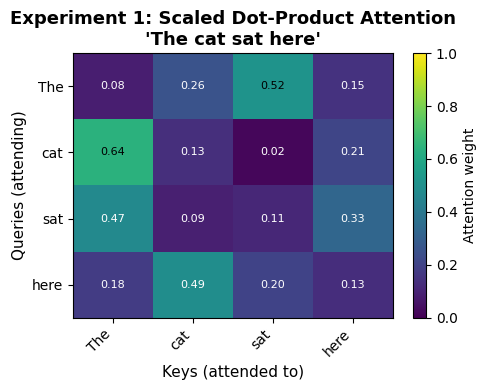

In [3]:
print("=" * 60)
print("🧪 Experiment 1: Scaled Dot-Product Attention from Scratch")
print("=" * 60)
print()

# Simulate a short sentence: ["The", "cat", "sat", "here"]
tokens = ["The", "cat", "sat", "here"]
seq_len = len(tokens)
d_k = 8   # key/query dimension
d_v = 8   # value dimension

np.random.seed(42)
Q = np.random.randn(seq_len, d_k)   # (4, 8)
K = np.random.randn(seq_len, d_k)   # (4, 8)
V = np.random.randn(seq_len, d_v)   # (4, 8)

print(f"Tokens:        {tokens}")
print(f"Sequence len:  {seq_len}")
print(f"Q/K dimension: {d_k}")
print(f"V dimension:   {d_v}")
print()

# Run attention
output, attention_weights = scaled_dot_product_attention(Q, K, V)

print("Attention weight matrix (rows=queries, cols=keys):")
print("  Each row sums to 1.0 (softmax output)")
print()
print(f"{'':6}", end="")
for t in tokens:
    print(f"{t:>8}", end="")
print()
for i, tok in enumerate(tokens):
    print(f"{tok:<6}", end="")
    for j in range(seq_len):
        print(f"{attention_weights[i,j]:>8.3f}", end="")
    print()

print()
print("Row sums (should all be ~1.0):", np.round(attention_weights.sum(axis=1), 4))

# Visualise
save_path = os.path.join(heatmap_dir, 'exp1_basic_attention.png')
plot_attention_heatmap(
    attention_weights, tokens,
    title="Experiment 1: Scaled Dot-Product Attention\n'The cat sat here'",
    save_path=save_path
)

### 🎯 TODO 1: Modify the Query Vector

**Task:** Change the query vector for the token `"cat"` (index 1) and observe how the attention distribution shifts.

The idea: different Q vectors represent different "things the model is looking for".

Modified attention weights for 'cat' query (row 1):
  Original: [0.641 0.133 0.017 0.209]
  Modified: [0.25 0.25 0.25 0.25]
  Modified 1 (Q[1]=5): [0.    0.063 0.934 0.003]
  Modified 2 (Q[1]=K[2]): [0.085 0.122 0.753 0.04 ]

✓ Heatmap saved to: ../outputs/attention_heatmaps/exp1_modified_query.png


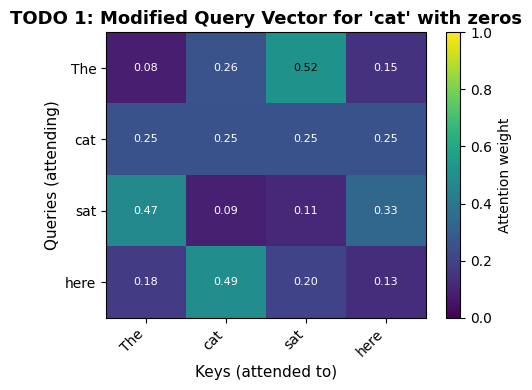

✓ Heatmap saved to: ../outputs/attention_heatmaps/exp1_modified_query_1.png


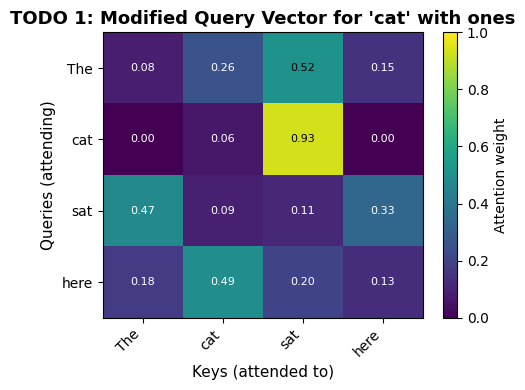

✓ Heatmap saved to: ../outputs/attention_heatmaps/exp1_modified_query_2.png


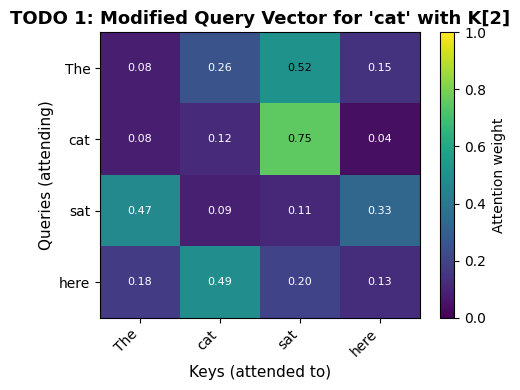

In [ ]:
# TODO 1: Experiment with different Q[1]=0

# Start with the original Q matrix
Q_modified = Q.copy()
Q_modified_1 = Q.copy()
Q_modified_2 = Q.copy()

# Modify the query for "cat" (row index 1)
# Try: make it all zeros, or a large positive value, or equal to K[2] (key of "sat")
Q_modified[1] = np.zeros(d_k)   # ← Change this! Try K[2], or np.ones(d_k)*5, etc.
Q_modified_1[1] = np.ones(d_k) * 5
Q_modified_2[1] = K[2]  # Equal to the key of "sat"
_, attn_modified = scaled_dot_product_attention(Q_modified, K, V)
_, attn_modified_1 = scaled_dot_product_attention(Q_modified_1, K, V)
_, attn_modified_2 = scaled_dot_product_attention(Q_modified_2, K, V)


print("=" * 60)
print("Modified attention weights for 'cat' query (row 1):")
print("  Original:", np.round(attention_weights[1], 3))
print("  Modified:", np.round(attn_modified[1], 3))
print("  Modified 1 (Q[1]=5):", np.round(attn_modified_1[1], 3))
print("  Modified 2 (Q[1]=K[2]):", np.round(attn_modified_2[1], 3))
print()

save_path_mod = os.path.join(heatmap_dir, 'exp1_modified_query.png')
save_path_mod_1 = os.path.join(heatmap_dir, 'exp1_modified_query_1.png')
save_path_mod_2 = os.path.join(heatmap_dir, 'exp1_modified_query_2.png')
plot_attention_heatmap(
    attn_modified, tokens,
    title="TODO 1: Modified Query Vector for 'cat' with zeros",
    save_path=save_path_mod
)
plot_attention_heatmap(
    attn_modified_1, tokens,
    title="TODO 1: Modified Query Vector for 'cat' * 5",
    save_path=save_path_mod_1
)
plot_attention_heatmap(
    attn_modified_2, tokens,
    title="TODO 1: Modified Query Vector for 'cat' with K[2]",
    save_path=save_path_mod_2
)

In [29]:

# TODO: Write your observation below
todo1_reflection = """
Describe:
- What Q vector change did you make?
    Q[1] was changed to all zeros, all fives, and equal to K[2] in three separate experiments.

- How did the attention distribution for 'cat' change?
    When Q[1] was set to all zeros, model treats all tokens as equally relevant--25% attention to each token.
    When Q[1] was set to all fives, will result a sharp attention. One token that happens to have a slightly higher sum in its Key vector will likely capture 99% of the attention, while the others drop to near-zero.
    When Q[1] was set equal to K[2], the attention distribution was concentrated on the third token.

- What does this tell you about how Q vectors control what a token attends to?
     
    When Q[1] was set to all zeros, The model becomes "unsure" and simply averages all surrounding information to stay safe.
    When Q[1] was set to all fives, If Q is too generic (like all fives), the attention mechanism breaks down and just gravitates toward whatever token has the highest variance in its embedding
    When Q[1] was set equal to K[2], If Q is high in "verb-seeking" dimensions, it will attend to verbs; if it is high in "subject-seeking" dimensions, it will attend to nouns.



"""

print("Your observation:")
print(todo1_reflection)

Your observation:

Describe:
- What Q vector change did you make?
    Q[1] was changed to all zeros, all fives, and equal to K[2] in three separate experiments.

- How did the attention distribution for 'cat' change?
    When Q[1] was set to all zeros, model treats all tokens as equally relevant--25% attention to each token.
    When Q[1] was set to all fives, will result a sharp attention. One token that happens to have a slightly higher sum in its Key vector will likely capture 99% of the attention, while the others drop to near-zero.
    When Q[1] was set equal to K[2], the attention distribution was concentrated on the third token.

- What does this tell you about how Q vectors control what a token attends to?

    When Q[1] was set to all zeros, The model becomes "unsure" and simply averages all surrounding information to stay safe.
    When Q[1] was set to all fives, If Q is too generic (like all fives), the attention mechanism breaks down and just gravitates toward whatever toke

---

## Part 2: Multi-Head Attention with BertViz

A single attention head captures one type of relationship. **Multi-head attention** runs several heads in parallel — one might capture grammatical dependencies, another semantic similarity, another positional proximity.

We'll use **BertViz** to interactively visualise attention heads in a real BERT model.

In [9]:
print("=" * 60)
print("🧪 Experiment 2: Multi-Head Attention with BertViz")
print("=" * 60)
print()

demo_sentence = "The quick brown fox jumps over the lazy dog"
print(f"Sentence: \"{demo_sentence}\"")
print()
print("Loading BERT model and computing attention...")
print("(First run downloads ~440MB — subsequent runs use cache)")
print()

multi_head_demo(
    sentence=demo_sentence,
    model_name="bert-base-uncased",
    save_dir=heatmap_dir
)

print()
print("💡 In the BertViz head view, each colour represents a different attention head.")
print("   Notice how different heads focus on different word relationships.")

🧪 Experiment 2: Multi-Head Attention with BertViz

Sentence: "The quick brown fox jumps over the lazy dog"

Loading BERT model and computing attention...
(First run downloads ~440MB — subsequent runs use cache)



/home/chris/Homework2-Submission/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading bert-base-uncased...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1728.31it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ BertViz available — rendering interactive view


<IPython.core.display.Javascript object>


💡 In the BertViz head view, each colour represents a different attention head.
   Notice how different heads focus on different word relationships.


### 🎯 TODO 2: Your Own Sentence

In [10]:
# TODO 2: Provide your own sentence and analyse what you see

# Use a sentence relevant to your project domain, or any sentence you find interesting
my_sentence = "The 3 most reliable tax declaration application."  # ← Change this!

print(f"My sentence: \"{my_sentence}\"")
print()

multi_head_demo(
    sentence=my_sentence,
    model_name="bert-base-uncased",
    save_dir=heatmap_dir
)


My sentence: "The 3 most reliable tax declaration application."

Loading bert-base-uncased...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1145.65it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ BertViz available — rendering interactive view


<IPython.core.display.Javascript object>

In [30]:

# TODO: Write your observation
todo2_reflection = """


Describe:
- Which words appear to have strong attention connections?
  3--most, reliable--most, tax--declaration
- Can you identify any heads that seem to focus on syntax vs. meaning?
  Syntax-Focused Heads care about how the words relate to each other grammatically.
  The 3 most is the Positional Head.
   applications is the Dependency Head.
   And . is the Delimiter Head.
- Does [CLS] (the first token) attend broadly or narrowly?
  In the first few layers (Layers 1–3), the [CLS] token attends broadly and relatively uniformly.

"""

print("Your observation:")
print(todo2_reflection)

Your observation:



Describe:
- Which words appear to have strong attention connections?
  3--most, reliable--most, tax--declaration
- Can you identify any heads that seem to focus on syntax vs. meaning?
  Syntax-Focused Heads care about how the words relate to each other grammatically.
  The 3 most is the Positional Head.
   applications is the Dependency Head.
   And . is the Delimiter Head.
- Does [CLS] (the first token) attend broadly or narrowly?
  In the first few layers (Layers 1–3), the [CLS] token attends broadly and relatively uniformly.




---

## Part 3: Positional Encoding

Transformers process all tokens **in parallel** — unlike RNNs, they have no built-in notion of order.
Positional encoding adds a unique signal to each position so the model can distinguish token order.

The original Transformer uses sinusoidal encoding:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right) \qquad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

🧪 Experiment 3: Sinusoidal Positional Encoding

Positional encoding shape: (50, 64)  (50 positions × 64 dims)

✓ Saved: ../outputs/attention_heatmaps/exp3_positional_encoding.png


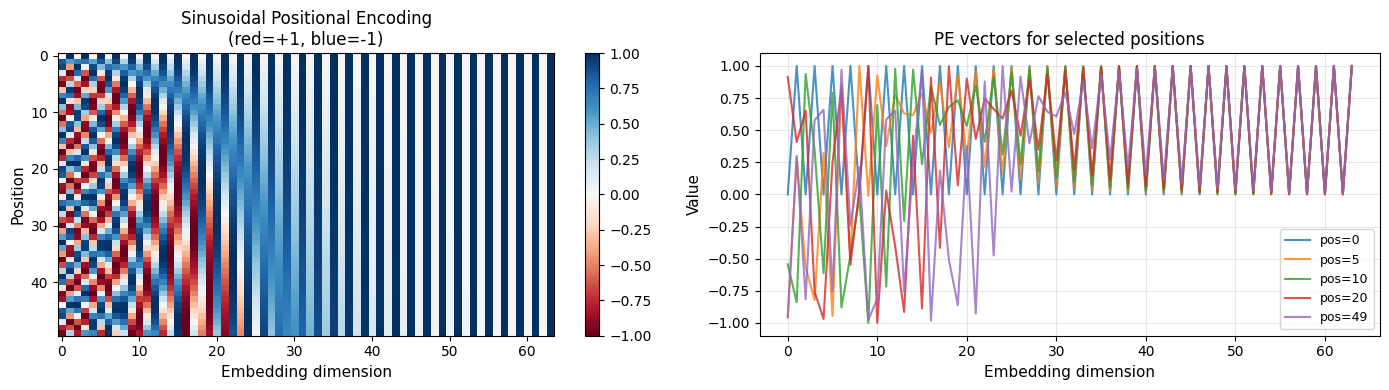


🔑 Key insight: Every position has a unique fingerprint across all dimensions.
   The model can learn to decode position from these signals.


In [6]:
print("=" * 60)
print("🧪 Experiment 3: Sinusoidal Positional Encoding")
print("=" * 60)
print()

def sinusoidal_pe(max_len: int, d_model: int) -> np.ndarray:
    """Compute sinusoidal positional encoding. Returns (max_len, d_model)."""
    pe  = np.zeros((max_len, d_model))
    pos = np.arange(max_len)[:, None]          # (max_len, 1)
    dim = np.arange(0, d_model, 2)             # even dimensions
    div = np.power(10000, dim / d_model)        # (d_model/2,)
    pe[:, 0::2] = np.sin(pos / div)
    pe[:, 1::2] = np.cos(pos / div)
    return pe

max_len = 50
d_model = 64
pe = sinusoidal_pe(max_len, d_model)

print(f"Positional encoding shape: {pe.shape}  ({max_len} positions × {d_model} dims)")
print()

# Plot: heatmap of PE matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full PE heatmap
im = axes[0].imshow(pe, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xlabel('Embedding dimension', fontsize=11)
axes[0].set_ylabel('Position', fontsize=11)
axes[0].set_title('Sinusoidal Positional Encoding\n(red=+1, blue=-1)', fontsize=12)
plt.colorbar(im, ax=axes[0])

# Right: PE curves for a few positions
for pos in [0, 5, 10, 20, 49]:
    axes[1].plot(pe[pos], label=f'pos={pos}', alpha=0.8)
axes[1].set_xlabel('Embedding dimension', fontsize=11)
axes[1].set_ylabel('Value', fontsize=11)
axes[1].set_title('PE vectors for selected positions', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
pe_path = os.path.join(heatmap_dir, 'exp3_positional_encoding.png')
plt.savefig(pe_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {pe_path}")
plt.show()

print()
print("🔑 Key insight: Every position has a unique fingerprint across all dimensions.")
print("   The model can learn to decode position from these signals.")

---

## Part 4: MiniTransformerBlock (PyTorch)

Let's wire everything together into a single Transformer encoder block:

```
Input → Multi-Head Self-Attention → Add & LayerNorm → FeedForward → Add & LayerNorm → Output
```

This is the repeating unit stacked 12× in BERT-base, 96× in GPT-3.

In [7]:
print("=" * 60)
print("🧪 Experiment 4: MiniTransformerBlock Forward Pass")
print("=" * 60)
print()

try:
    import torch

    # Create the block
    d_model   = 64
    num_heads = 4
    d_ff      = 256

    block = MiniTransformerBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff)
    block.eval()

    print(f"MiniTransformerBlock config:")
    print(f"  d_model   = {d_model}  (embedding dimension)")
    print(f"  num_heads = {num_heads}  (attention heads)")
    print(f"  d_ff      = {d_ff}  (feed-forward inner dim)")
    print(f"  d_head    = {d_model // num_heads}  (per-head dimension)")
    print(f"  Parameters: {block.count_parameters():,}")
    print()

    # Dummy input: batch=2, seq_len=10, d_model=64
    batch_size = 2
    seq_len    = 10
    x = torch.randn(batch_size, seq_len, d_model)

    print(f"Input  shape: {tuple(x.shape)}  (batch, seq_len, d_model)")

    with torch.no_grad():
        output = block(x)

    print(f"Output shape: {tuple(output.shape)}  ← same shape as input! ✅")
    print()
    print("✅ Forward pass successful")
    print()
    print("🔑 Key insight: The Transformer block is shape-preserving.")
    print("   Stack N of these → N-layer Transformer.")
    print("   Output has the same shape as input — perfect for residual connections.")

except ImportError:
    print("⚠️  PyTorch not installed — skipping this experiment")
    print("   Install: pip install torch")

🧪 Experiment 4: MiniTransformerBlock Forward Pass

MiniTransformerBlock config:
  d_model   = 64  (embedding dimension)
  num_heads = 4  (attention heads)
  d_ff      = 256  (feed-forward inner dim)
  d_head    = 16  (per-head dimension)
  Parameters: 49,728

Input  shape: (2, 10, 64)  (batch, seq_len, d_model)
Output shape: (2, 10, 64)  ← same shape as input! ✅

✅ Forward pass successful

🔑 Key insight: The Transformer block is shape-preserving.
   Stack N of these → N-layer Transformer.
   Output has the same shape as input — perfect for residual connections.


---

## Part 5: Ask Claude to Explain Its Own Architecture

Now let's use what we've built to compare *our* implementation against Claude's explanation of how it works.

In [23]:
import importlib

import src.llm_client

importlib.reload(src.llm_client)

from src.llm_client import LLMClient  # re-import!
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from src.llm_client import LLMClient


print("=" * 60)
print("🧪 Experiment 5: Ask Claude About Its Architecture")
print("=" * 60)
print()

prompt = (
    "You are a Transformer-based language model. "
    "Explain in exactly 5 bullet points what happens internally when you process "
    "the sentence 'The cat sat on the mat'. "
    "Focus on: tokenization → embedding → attention → output. "
    "Be technically accurate but concise."
)

start = time.time()
client = LLMClient(path=config.PATH)

# response = client.generate(
#     prompt=prompt,
#     # system="You are a concise ML course assistant. Reply in 1 bullet points max.",
#     max_tokens=5000,
#     temperature=0.5,
# )
# The generate() method in Path C defaults to Claude (use_claude=True). To explicitly use Ollama, change to use_claude=False
# same thing, you can switch the model by adding model label. 
# # uncomment the following if you using Model C (mix model)

# response= client.generate(prompt=prompt, max_tokens=5000, temperature=0.5, use_claude=False, model="gemini-3-flash-preview")
response = client.generate(prompt=prompt, max_tokens=5000, temperature=0.5, use_claude=False, model="gemini-3-flash-preview")
# response = client.generate(prompt=prompt, max_tokens=5000, temperature=0.5) 
elapsed = time.time() - start
# print(response)
if "error" not in response:
    tracker.add_call(response)
    print(f"✅ Response in {elapsed:.1f}s")
    print(format_response(response, verbose=True))
else:
    print(f"❌ Error: {response['error']}")

🧪 Experiment 5: Ask Claude About Its Architecture

✓ Gemini client initialized (gemini-3-flash-preview)
✅ Response in 9.4s
Model: gemini-3-flash-preview
Tokens: 51 in, 215 out
Stop reason: FinishReason.STOP
* **Tokenization:** The sentence is segmented into discrete units (e.g., ["The", "cat", "sat", "on", "the", "mat"]) and each token is mapped to a unique integer index from a pre-defined vocabulary.
* **Embedding & Positional Encoding:** These indices are converted into high-dimensional vectors, which are then summed with positional encodings to provide the model with the spatial order of the words in the sequence.
* **Self-Attention Mechanism:** Each token generates Query, Key, and Value vectors to calculate attention scores, allowing the model to weight the relevance of "cat" relative to "sat" and "mat" to capture contextual dependencies.
* **Layered Transformation:** The contextualized vectors pass through multiple Transformer blocks, utilizing multi-head attention and feed-forwar

### 🎯 TODO 3: Ask Claude About Your Confusing Component

Pick the part of Transformer architecture you found most confusing or interesting and ask Claude to explain it.

In [26]:
# TODO 3: Ask Claude about a component you want to understand better

my_question = """
Why does Layer Normalization in Transformers normalize across the feature dimension
(not the batch dimension like BatchNorm)?  What goes wrong if you use BatchNorm instead?
"""  # ← Change this to your own question!

print("=" * 60)
print("🎯 TODO 3: My Architecture Question")
print("=" * 60)
print(f"Question: {my_question.strip()}")
print()

start = time.time()
response_todo3 = client.generate(
    prompt=my_question,
    system="You are an expert ML educator. Give a clear, technically accurate answer in under 200 words.",
    max_tokens=4000,
    temperature=0.3,
)
elapsed = time.time() - start

if "error" not in response_todo3:
    tracker.add_call(response_todo3)
    print(format_response(response_todo3, verbose=True))
else:
    print(f"❌ Error: {response_todo3['error']}")


🎯 TODO 3: My Architecture Question
Question: Why does Layer Normalization in Transformers normalize across the feature dimension
(not the batch dimension like BatchNorm)?  What goes wrong if you use BatchNorm instead?

Model: gemini-3-flash-preview
Tokens: 57 in, 262 out
Stop reason: FinishReason.STOP
Layer Normalization (LN) normalizes across the **feature dimension** for each token independently. This is preferred over Batch Normalization (BN) in Transformers for three primary reasons:

1.  **Variable Sequence Lengths:** BN calculates statistics across the batch at each position. Since NLP sequences vary in length, padding creates "dead" values that destabilize batch statistics, making them unreliable for shorter or longer sequences.
2.  **Batch Size Independence:** Transformers are memory-intensive, often forcing small batch sizes. BN requires large batches to accurately estimate mean and variance; LN works identically whether the batch size is 1 or 1,000, ensuring stable gradients.

In [27]:

# TODO: Write what you learned
todo3_reflection = """
[YOUR REFLECTION HERE]

- What did you ask about?
    LN vs BN
- What did you learn from the answer?
 Use BN when:
Have large batch sizes
Typical in CNNs (images)
Training is stable with batches
Use LN when:
Batch size is small or varies
Using Transformers / NLP models
Want consistency between training & inference

- How does this connect to what we implemented in experiments 1–4?

If results are unstable → try switching BN → LN
If have large, consistent batches → BN can give slightly better performance
If unsure → LN is the safer default (especially in modern models)

"""

print()
print("My reflection:")
print(todo3_reflection)


My reflection:

[YOUR REFLECTION HERE]

- What did you ask about?
    LN vs BN
- What did you learn from the answer?
 Use BN when:
Have large batch sizes
Typical in CNNs (images)
Training is stable with batches
Use LN when:
Batch size is small or varies
Using Transformers / NLP models
Want consistency between training & inference

- How does this connect to what we implemented in experiments 1–4?

If results are unstable → try switching BN → LN
If have large, consistent batches → BN can give slightly better performance
If unsure → LN is the safer default (especially in modern models)




## Summary & Reflection

In [32]:
# Combine all reflections
my_sentence = "The 3 most reliable tax declaration application." 
my_question = """
Why does Layer Normalization in Transformers normalize across the feature dimension
(not the batch dimension like BatchNorm)?  What goes wrong if you use BatchNorm instead?
"""  # ← Change this to your own question!
full_reflection = f"""
### Experiment 1 — Scaled Dot-Product Attention

Q/K/V dimensions: {d_k}/{d_k}/{d_v}
Tokens: {tokens}

**What I observed when modifying the Q vector:**
{todo1_reflection.strip()}

---

### Experiment 2 — Multi-Head Attention (BertViz)

My sentence: "{my_sentence}"

**What I observed in the attention heads:**
{todo2_reflection.strip()}

---

### TODO 3 — Architecture Question

My question: {my_question.strip()}

**What I learned:**
{todo3_reflection.strip()}
"""

reflection_file = append_to_reflection(
    notebook="02",
    section_title="Transformer Architecture Insights",
    reflection_content=full_reflection,
    output_dir=os.path.join('..', 'outputs')
)

print(f"✅ Reflection saved: {reflection_file}")
print()

tracker.report()

✅ Reflection saved: ../outputs/homework_reflection.md

💰 API COST REPORT
Total API calls:     3
Total input tokens:  165
Total output tokens: 492
Total cost:          $0.0079

Last 3 calls:
  1. [19:36:02] 3 — 51in/215out — $0.0034
  2. [19:37:27] 3 — 57in/15out — $0.0004
  3. [19:38:28] 3 — 57in/262out — $0.0041


## ✅ Notebook 02 Complete!

**What you accomplished:**
- ✅ Implemented scaled dot-product attention from scratch in NumPy
- ✅ Visualised multi-head attention with BertViz (or matplotlib fallback)
- ✅ Plotted sinusoidal positional encoding and understood why it works
- ✅ Ran a MiniTransformerBlock forward pass in PyTorch
- ✅ Asked Claude to explain its own architecture and compared to your implementation
- ✅ Saved attention heatmaps to `outputs/attention_heatmaps/`

**Key concepts:**
- Attention = weighted average of values, weights determined by query-key similarity
- Multi-head = multiple attention patterns running in parallel
- Positional encoding = unique signal added to each position's embedding
- Residual + LayerNorm = enables deep stacking without gradient vanishing

**Next:** Open **Notebook 03: Tokenization** 🔤